# Playground V1
## 0. Imports and Set-Up:

### 0.1 Imports, Seed-Setting, Plotting-Helper-Function:

In [1]:
from sklearn.cluster import AgglomerativeClustering, KMeans, SpectralClustering
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances, adjusted_rand_score

import numpy as np

import matplotlib.pyplot as plt

In [2]:
import sys
print("Interpreter:", sys.executable)

import carve
print("carve from:", carve.__file__)

import inspect
print("Public names:", [n for n in dir(carve) if not n.startswith("_")])
print("Classes:", [n for n, o in inspect.getmembers(carve, inspect.isclass) if o.__module__.startswith("carve")])
print("Functions:", [n for n, o in inspect.getmembers(carve, inspect.isfunction) if o.__module__.startswith("carve")])

Interpreter: /Users/kaiwycik/Documents/GitHub/ClusteringValidation/.venv/bin/python
carve from: /Users/kaiwycik/Documents/GitHub/ClusteringValidation/src/carve/__init__.py
Public names: ['CARVE', 'SpectralClusteringCARVE', 'api', 'cluster', 'config', 'grids']
Classes: ['CARVE', 'SpectralClusteringCARVE']
Functions: []


In [3]:
import carve.sim
print("carve.sim from:", carve.sim.__file__)

import inspect
print("Public names:", [n for n in dir(carve.sim) if not n.startswith("_")])
print("Classes:", [n for n, o in inspect.getmembers(carve.sim, inspect.isclass) if o.__module__.startswith("carve.sim")])
print("Functions:", [n for n, o in inspect.getmembers(carve.sim, inspect.isfunction) if o.__module__.startswith("carve.sim")])

carve.sim from: /Users/kaiwycik/Documents/GitHub/ClusteringValidation/src/carve/sim/__init__.py
Public names: ['ScDesign3Simulator', 'api', 'simulate_clusters']
Classes: ['ScDesign3Simulator']
Functions: ['simulate_clusters']


In [4]:
from carve import CARVE
from carve.config import ValidatorConfig

from carve.sim import simulate_clusters, ScDesign3Simulator

---

## 1. Playground

In [5]:
%env PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning

env: PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning


In [6]:
from sklearn.datasets import fetch_openml

X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)

X.shape, y.shape

((70000, 784), (70000,))

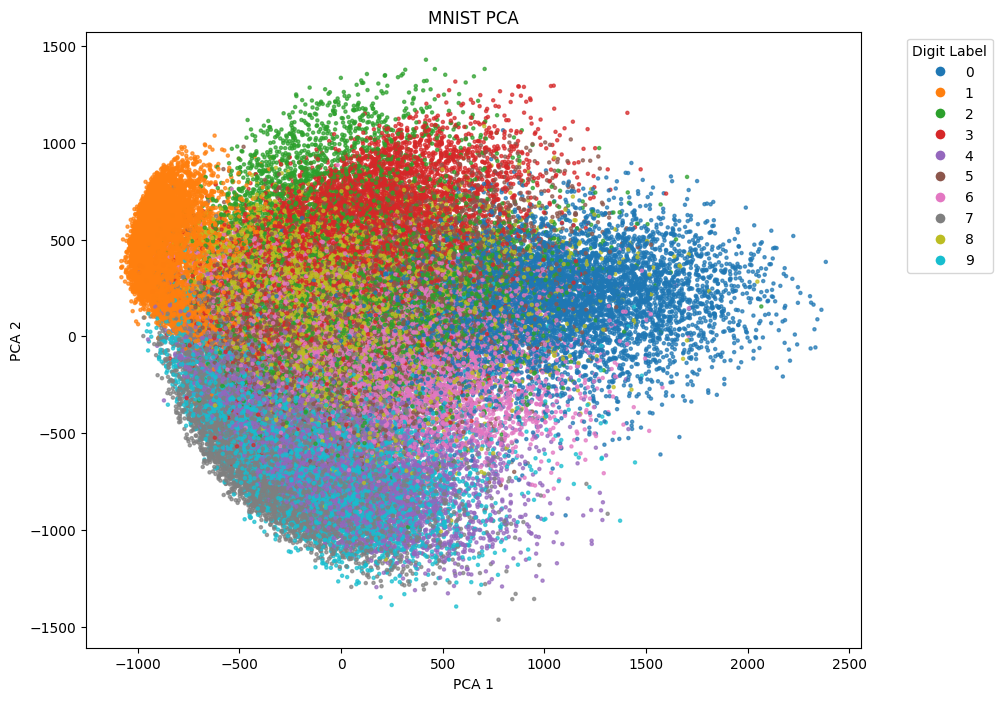

In [7]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y.astype(int), cmap='tab10', s=5, alpha=0.7)
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('MNIST PCA')

handles = []
labels = np.unique(y)
for label in labels:
    handles.append(plt.Line2D([], [], marker='o', color='w', markerfacecolor=scatter.cmap(scatter.norm(int(label))), markersize=8, label=str(label)))
plt.legend(handles=handles, title='Digit Label', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

In [8]:
rng = np.random.default_rng(seed=0)
idx = rng.choice(X.shape[0], size=500, replace=False)
X_sub = X[idx]
y_sub = y[idx]

In [9]:
# pairwise squared Euclidean distances
D2 = pairwise_distances(X_sub, metric='sqeuclidean')
median_d2 = np.median(D2[np.triu_indices_from(D2, k=1)])
gamma = 1.0 / (2.0 * median_d2) if median_d2 > 0 else 1.0

In [10]:
# spectral clustering
n_clusters = len(np.unique(y))
spectral = SpectralClustering(n_clusters=n_clusters, gamma=gamma, affinity='rbf', random_state=42, n_jobs=-1)
labels_pred = spectral.fit_predict(X_sub)

# get ARI
ari = adjusted_rand_score(y_sub.astype(str), labels_pred)
print("ARI:", ari)

ARI: 0.3889420197008759


ARI of 0.3889 --> can't expect CARVE to work well on this without any pre-processing. 

In [11]:
cfg1 = ValidatorConfig(
    X=X_sub,
    ref_labels=y_sub, 
    B=100,
    model_grids=[(SpectralClustering, {"n_clusters": [8, 9, 10, 11, 12], 'gamma': [gamma]})]
)

val1 = CARVE(cfg1)
val1.validate(random_preprocess=True, random_state=42)

Grid configs:   0%|          | 0/5 [00:00<?, ?it/s]

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


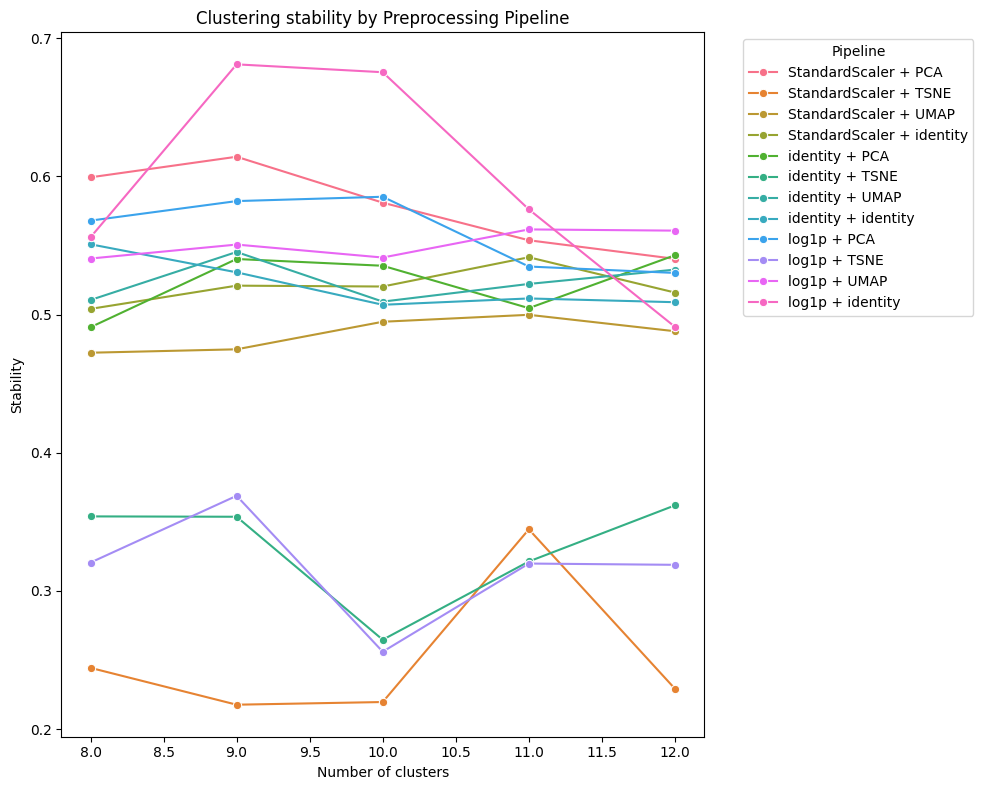

In [12]:
val1.plot_preprocessing()

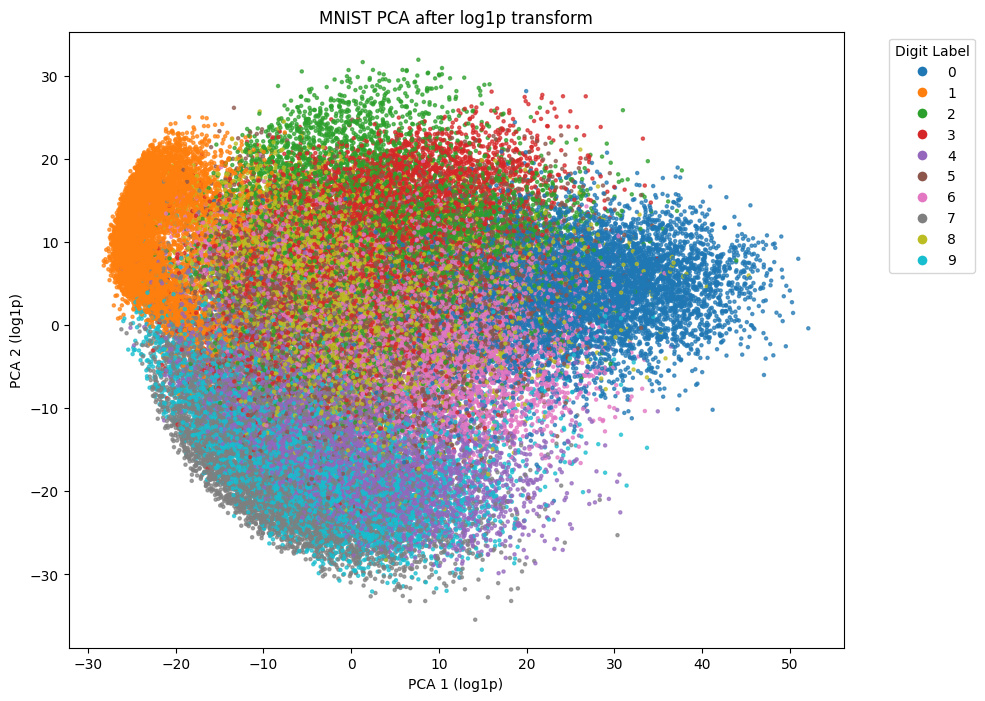

In [13]:
X_log1p = np.log1p(X)
pca_log1p = PCA(n_components=2)
X_log1p_pca = pca_log1p.fit_transform(X_log1p)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_log1p_pca[:, 0], X_log1p_pca[:, 1], c=y.astype(int), cmap='tab10', s=5, alpha=0.7)
plt.xlabel('PCA 1 (log1p)')
plt.ylabel('PCA 2 (log1p)')
plt.title('MNIST PCA after log1p transform')

handles = []
labels = np.unique(y)
for label in labels:
    handles.append(plt.Line2D([], [], marker='o', color='w', markerfacecolor=scatter.cmap(scatter.norm(int(label))), markersize=8, label=str(label)))
plt.legend(handles=handles, title='Digit Label', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

In [14]:
rng = np.random.default_rng(seed=0)
idx = rng.choice(X.shape[0], size=500, replace=False)
X_log1p_sub = X_log1p[idx]
y_log1p_sub = y[idx]

In [15]:
# pairwise squared Euclidean distances
D2 = pairwise_distances(X_log1p_sub, metric='sqeuclidean')
median_d2 = np.median(D2[np.triu_indices_from(D2, k=1)])
gamma = 1.0 / (2.0 * median_d2) if median_d2 > 0 else 1.0

In [16]:
# spectral clustering
n_clusters = len(np.unique(y))
spectral = SpectralClustering(n_clusters=n_clusters, gamma=gamma, affinity='rbf', random_state=42, n_jobs=-1)
labels_log1p_pred = spectral.fit_predict(X_log1p_sub)

# get ARI
ari = adjusted_rand_score(y_log1p_sub.astype(str), labels_log1p_pred)
print("ARI:", ari)

ARI: 0.464198608721444


In [ ]:
cfg1 = ValidatorConfig(
    X=X_log1p_sub,
    ref_labels=y_log1p_sub, 
    B=100,
    K=[8, 9, 10, 11, 12]
    # model_grids=[(SpectralClustering, {"n_clusters": [8, 9, 10, 11, 12], 'gamma': [gamma]})]
)

val2 = CARVE(cfg1)
val2.validate(random_preprocess=True, random_state=42)

Grid configs:   0%|          | 0/45 [00:00<?, ?it/s]

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [ ]:
val2.plot_global()